# 심장병 예측 머신러닝 프로젝트

1. 탐색적 데이터 분석 (EDA)
2. 데이터 전처리
3. 앙상블 모델 비교 (최적화 전)
4. 하이퍼파라미터 최적화 (GridSearch & Optuna)
5. 최적화 전/후 비교
6. 모델 해석 (SHAP)

In [94]:
# !pip install catboost optuna shap koreanize-matplotlib -q

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
# 성능지표 분류 -> 회귀
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, f1_score
# 분류 모델 -> 회귀 모델
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
# 하이퍼파라미터 최적화
import optuna
# 설명가능한 AI
import shap

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
# 차트에서 '-' 깨짐 현상 방지
plt.rcParams['axes.unicode_minus'] = False
optuna.logging.set_verbosity(optuna.logging.WARNING)

## 1. 데이터 로드 및 EDA

In [96]:
# from google.colab import files

# uploaded = files.upload()

# for fn in uploaded.keys():
#   print(f'파일 업로드 완료"{fn}" {len(uploaded[fn])} bytes')

In [3]:
df = pd.read_csv('heart_disease2.csv')
print(f'데이터 크기: {df.shape}')
df.head()

데이터 크기: (1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [4]:
print('데이터 타입:')
print(df.dtypes)
print(f'\n결측치: {df.isnull().sum().sum()}')
print(f'\n타겟 분포:')
print(df['target'].value_counts())

데이터 타입:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

결측치: 0

타겟 분포:
target
1    564
0    461
Name: count, dtype: int64


In [5]:
print(df['target'].value_counts(normalize=True))

target
1    0.550244
0    0.449756
Name: proportion, dtype: float64


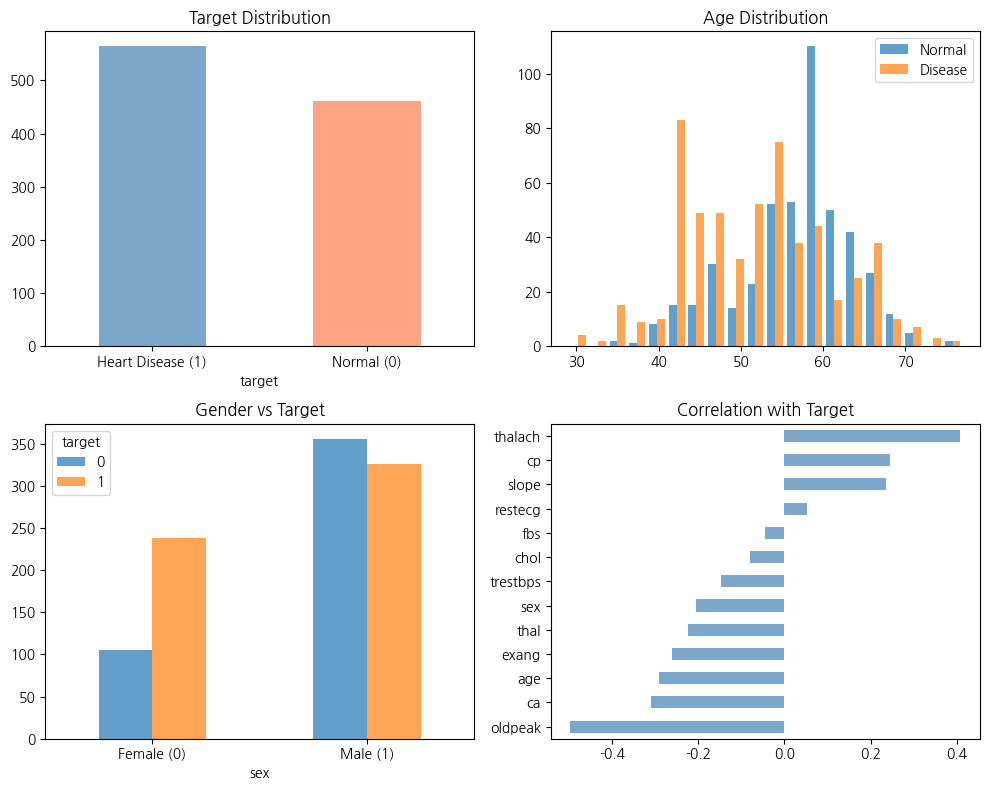

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

df['target'].value_counts().plot(kind='bar', ax=axes[0, 0], color=['steelblue', 'coral'], alpha=0.7)
axes[0, 0].set_title('Target Distribution')
axes[0, 0].set_xticklabels(['Heart Disease (1)', 'Normal (0)'], rotation=0)

axes[0, 1].hist([df[df['target']==0]['age'], df[df['target']==1]['age']], label=['Normal', 'Disease'], bins=20, alpha=0.7)
axes[0, 1].set_title('Age Distribution')
axes[0, 1].legend()

pd.crosstab(df['sex'], df['target']).plot(kind='bar', ax=axes[1, 0], alpha=0.7)
axes[1, 0].set_title('Gender vs Target')
axes[1, 0].set_xticklabels(['Female (0)', 'Male (1)'], rotation=0)

corr_with_target = df.corr()['target'].drop('target').sort_values()
corr_with_target.plot(kind='barh', ax=axes[1, 1], alpha=0.7, color='steelblue')
axes[1, 1].set_title('Correlation with Target')

plt.tight_layout()
plt.show()

## 2. 데이터 전처리

In [7]:
y = df['target']
X = df.drop('target', axis=1)
print(f'피처 수: {X.shape[1]}')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

피처 수: 13
Train: (820, 13), Test: (205, 13)


## 3. 모델 비교 (최적화 전)

In [8]:
base_models = {
    'RandomForest': RandomForestClassifier(random_state=RANDOM_STATE),
    'ExtraTrees': ExtraTreesClassifier(random_state=RANDOM_STATE),
    'XGBoost': XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss', use_label_encoder=False),
    'LightGBM': LGBMClassifier(random_state=RANDOM_STATE, verbose=-1),
    'CatBoost': CatBoostClassifier(random_state=RANDOM_STATE, verbose=0)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
base_cv_results = []

print('=== 최적화 전 (Base Models) ===')
for name, model in base_models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')
    base_cv_results.append({'Model': name, 'CV_Accuracy': scores.mean(), 'CV_Std': scores.std()})
    print(f'{name}: {scores.mean():.4f} (+/- {scores.std():.4f})')

base_cv_df = pd.DataFrame(base_cv_results)
base_cv_df

=== 최적화 전 (Base Models) ===
RandomForest: 0.8622 (+/- 0.0285)
ExtraTrees: 0.8524 (+/- 0.0251)
XGBoost: 0.8573 (+/- 0.0346)
LightGBM: 0.8573 (+/- 0.0361)
CatBoost: 0.8585 (+/- 0.0209)


,Model,CV_Accuracy,CV_Std
0,RandomForest,0.862195,0.028496
1,ExtraTrees,0.852439,0.025111
2,XGBoost,0.857317,0.034622
3,LightGBM,0.857317,0.036094
4,CatBoost,0.858537,0.020910


## 4. 하이퍼파라미터 최적화
### 4.1 GridSearchCV

In [9]:
param_grids = {
    'RandomForest': {
        'n_estimators': [50, 100, 200],
        'max_depth': [5, 10, 15],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2]
    },
    'ExtraTrees': {
        'n_estimators': [50, 100, 200],
        'max_depth': [5, 10, 15],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2]},
    'XGBoost': {
        'n_estimators': [50, 100, 200],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.1, 0.2],
        'subsample': [0.8, 1.0]
    },
    'LightGBM': {
        'n_estimators': [50, 100, 200],
        'max_depth': [3, 5, 7],
        'num_leaves': [7, 15, 31],
        'learning_rate': [0.01, 0.1, 0.2],
        'subsample': [0.8, 1.0],
        'colsample_bytree': [0.8, 1.0]
    },
    'CatBoost': {
        'iterations': [50, 100, 200],
        'depth': [3, 5, 7],
        'learning_rate': [0.01, 0.1, 0.2]
    }
}

In [10]:
grid_models = {
    'RandomForest': RandomForestClassifier(random_state=RANDOM_STATE),
    'ExtraTrees': ExtraTreesClassifier(random_state=RANDOM_STATE),
    'XGBoost': XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss', use_label_encoder=False),
    'LightGBM': LGBMClassifier(random_state=RANDOM_STATE, verbose=-1,n_jobs=1,force_col_wise=True),
    'CatBoost': CatBoostClassifier(random_state=RANDOM_STATE, verbose=0)
}

grid_best_params = {}
grid_best_scores = {}
grid_optimized_models = {}

print('=== GridSearchCV 최적화 ===')
for name, model in grid_models.items():
    print(f'\n[{name}] GridSearch 진행 중...')
    grid_search = GridSearchCV(estimator=model, param_grid=param_grids[name], cv=cv, scoring='accuracy', n_jobs=-1)
    grid_search.fit(X_train, y_train)
    grid_best_params[name] = grid_search.best_params_
    grid_best_scores[name] = grid_search.best_score_
    grid_optimized_models[name] = grid_search.best_estimator_
    print(f'Best Score: {grid_search.best_score_:.4f}')
    print(f'Best Params: {grid_search.best_params_}')

=== GridSearchCV 최적화 ===

[RandomForest] GridSearch 진행 중...
Best Score: 0.8622
Best Params: {'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

[ExtraTrees] GridSearch 진행 중...
Best Score: 0.8561
Best Params: {'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

[XGBoost] GridSearch 진행 중...
Best Score: 0.8671
Best Params: {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}

[LightGBM] GridSearch 진행 중...
Best Score: 0.8780
Best Params: {'colsample_bytree': 0.8, 'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 200, 'num_leaves': 15, 'subsample': 0.8}

[CatBoost] GridSearch 진행 중...
Best Score: 0.8793
Best Params: {'depth': 7, 'iterations': 200, 'learning_rate': 0.1}




```
# 코드로 형식 지정됨
```

### 4.2 Optuna (HPO: Hyper Parameter Optimization) 라이브러리

1. Ojbective 함수
- 목표 정하기(하이퍼파라미터)
- 모델객체 만들기
- 성능평가 방법 지정하기
1. Study create(TPE sampler)
1. optimize()


In [11]:
def create_objective(model_name):
    def objective(trial):
        if model_name == 'RandomForest':
            params = {'n_estimators': trial.suggest_int('n_estimators', 50, 300), 'max_depth': trial.suggest_int('max_depth', 3, 15), 'min_samples_split': trial.suggest_int('min_samples_split', 2, 10), 'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 5), 'random_state': RANDOM_STATE}
            model = RandomForestClassifier(**params)
        elif model_name == 'ExtraTrees':
            params = {'n_estimators': trial.suggest_int('n_estimators', 50, 300), 'max_depth': trial.suggest_int('max_depth', 3, 15), 'min_samples_split': trial.suggest_int('min_samples_split', 2, 10), 'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 5), 'random_state': RANDOM_STATE}
            model = ExtraTreesClassifier(**params)
        elif model_name == 'XGBoost':
            params = {'n_estimators': trial.suggest_int('n_estimators', 50, 300), 'max_depth': trial.suggest_int('max_depth', 3, 10), 'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3), 'subsample': trial.suggest_float('subsample', 0.6, 1.0), 'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0), 'random_state': RANDOM_STATE, 'eval_metric': 'logloss', 'use_label_encoder': False}
            model = XGBClassifier(**params)
        elif model_name == 'LightGBM':
            params = {'n_estimators': trial.suggest_int('n_estimators', 50, 300), 'max_depth': trial.suggest_int('max_depth', 3, 10), 'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3), 'subsample': trial.suggest_float('subsample', 0.6, 1.0), 'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0), 'random_state': RANDOM_STATE, 'verbose': -1}
            model = LGBMClassifier(**params)
        elif model_name == 'CatBoost':
            params = {'iterations': trial.suggest_int('iterations', 50, 300), 'depth': trial.suggest_int('depth', 3, 10), 'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3), 'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10), 'random_state': RANDOM_STATE, 'verbose': 0}
            model = CatBoostClassifier(**params)
        scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')
        return scores.mean()
    return objective

### 모델 객체 3번 생성
1. Vanilla 모델
1. GridSearCV 모델
1. Optuna용 모델


In [13]:
optuna_best_params = {}
optuna_best_scores = {}

optuna_models = {
    'RandomForest': RandomForestClassifier(random_state=RANDOM_STATE),
    'ExtraTrees': ExtraTreesClassifier(random_state=RANDOM_STATE),
    'XGBoost': XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss', use_label_encoder=False),
    'LightGBM': LGBMClassifier(random_state=RANDOM_STATE, verbose=-1),
    'CatBoost': CatBoostClassifier(random_state=RANDOM_STATE, verbose=0)
}

print('=== Optuna 최적화 ===')
for name in optuna_models.keys():
    print(f'\n[{name}] Optuna 최적화 중...')
    study = optuna.create_study(direction='maximize')
    study.optimize(create_objective(name), n_trials=100, show_progress_bar=True,n_jobs=1)
    optuna_best_params[name] = study.best_params
    optuna_best_scores[name] = study.best_value
    print(f'Best Score: {study.best_value:.4f}')
    print(f'Best Params: {study.best_params}')

=== Optuna 최적화 ===

[RandomForest] Optuna 최적화 중...


  0%|          | 0/100 [00:00<?, ?it/s]

Best Score: 0.8634
Best Params: {'n_estimators': 224, 'max_depth': 11, 'min_samples_split': 2, 'min_samples_leaf': 1}

[ExtraTrees] Optuna 최적화 중...


  0%|          | 0/100 [00:00<?, ?it/s]

Best Score: 0.8671
Best Params: {'n_estimators': 62, 'max_depth': 14, 'min_samples_split': 3, 'min_samples_leaf': 1}

[XGBoost] Optuna 최적화 중...


  0%|          | 0/100 [00:00<?, ?it/s]

Best Score: 0.8732
Best Params: {'n_estimators': 241, 'max_depth': 8, 'learning_rate': 0.1072262867303583, 'subsample': 0.7539191159995582, 'colsample_bytree': 0.926871983624993}

[LightGBM] Optuna 최적화 중...


  0%|          | 0/100 [00:00<?, ?it/s]

Best Score: 0.8780
Best Params: {'n_estimators': 160, 'max_depth': 10, 'learning_rate': 0.2875634773548606, 'subsample': 0.828228334936191, 'colsample_bytree': 0.7576988944353099}

[CatBoost] Optuna 최적화 중...


  0%|          | 0/100 [00:00<?, ?it/s]

Best Score: 0.8854
Best Params: {'iterations': 282, 'depth': 8, 'learning_rate': 0.18688826067414144, 'l2_leaf_reg': 1.7811376739874738}


In [14]:
optuna_best_params.items()

dict_items([('RandomForest', {'n_estimators': 224, 'max_depth': 11, 'min_samples_split': 2, 'min_samples_leaf': 1}), ('ExtraTrees', {'n_estimators': 62, 'max_depth': 14, 'min_samples_split': 3, 'min_samples_leaf': 1}), ('XGBoost', {'n_estimators': 241, 'max_depth': 8, 'learning_rate': 0.1072262867303583, 'subsample': 0.7539191159995582, 'colsample_bytree': 0.926871983624993}), ('LightGBM', {'n_estimators': 160, 'max_depth': 10, 'learning_rate': 0.2875634773548606, 'subsample': 0.828228334936191, 'colsample_bytree': 0.7576988944353099}), ('CatBoost', {'iterations': 282, 'depth': 8, 'learning_rate': 0.18688826067414144, 'l2_leaf_reg': 1.7811376739874738})])

In [15]:
optuna_optimized_models = {}
for name, params in optuna_best_params.items():
    p = params.copy()
    if name == 'RandomForest':
        p['random_state'] = RANDOM_STATE
        optuna_optimized_models[name] = RandomForestClassifier(**p)
    elif name == 'ExtraTrees':
        p['random_state'] = RANDOM_STATE
        optuna_optimized_models[name] = ExtraTreesClassifier(**p)
    elif name == 'XGBoost':
        p['random_state'] = RANDOM_STATE
        p['eval_metric'] = 'logloss'
        p['use_label_encoder'] = False
        optuna_optimized_models[name] = XGBClassifier(**p)
    elif name == 'LightGBM':
        p['random_state'] = RANDOM_STATE
        p['verbose'] = -1
        optuna_optimized_models[name] = LGBMClassifier(**p)
    elif name == 'CatBoost':
        p['random_state'] = RANDOM_STATE
        p['verbose'] = 0
        optuna_optimized_models[name] = CatBoostClassifier(**p)
print('Optuna 최적화 모델 생성 완료')

Optuna 최적화 모델 생성 완료


## 5. 최적화 전/후 비교

In [16]:
def evaluate_models(models, X_tr, X_te, y_tr, y_te):
    results = []
    for name, model in models.items():
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_te)
        y_prob = model.predict_proba(X_te)[:, 1]
        results.append({'Model': name, 'Accuracy': accuracy_score(y_te, y_pred), 'F1': f1_score(y_te, y_pred), 'ROC-AUC': roc_auc_score(y_te, y_prob)})
    return pd.DataFrame(results)

base_test_df = evaluate_models(base_models, X_train, X_test, y_train, y_test)
grid_test_df = evaluate_models(grid_optimized_models, X_train, X_test, y_train, y_test)
optuna_test_df = evaluate_models(optuna_optimized_models, X_train, X_test, y_train, y_test)

print('=== Base Models ===')
display(base_test_df)
print('\n=== GridSearch Models ===')
display(grid_test_df)
print('\n=== Optuna Models ===')
display(optuna_test_df)

=== Base Models ===


,Model,Accuracy,F1,ROC-AUC
0,RandomForest,0.902439,0.915254,0.954742
1,ExtraTrees,0.873171,0.885965,0.946326
2,XGBoost,0.868293,0.883117,0.948730
3,LightGBM,0.897561,0.909871,0.952963
4,CatBoost,0.892683,0.904348,0.950077



=== GridSearch Models ===


,Model,Accuracy,F1,ROC-AUC
0,RandomForest,0.897561,0.910638,0.956570
1,ExtraTrees,0.897561,0.907489,0.941372
2,XGBoost,0.887805,0.897778,0.952482
3,LightGBM,0.863415,0.878261,0.940362
4,CatBoost,0.897561,0.909091,0.957868



=== Optuna Models ===


,Model,Accuracy,F1,ROC-AUC
0,RandomForest,0.882927,0.898305,0.953059
1,ExtraTrees,0.868293,0.882096,0.928242
2,XGBoost,0.907317,0.915556,0.953059
3,LightGBM,0.892683,0.902655,0.953444
4,CatBoost,0.882927,0.898305,0.962486


In [17]:
comparison_df = pd.DataFrame({'Model': base_test_df['Model'], 'Base_Acc': base_test_df['Accuracy'].round(4), 'Grid_Acc': grid_test_df['Accuracy'].round(4), 'Optuna_Acc': optuna_test_df['Accuracy'].round(4), 'Base_AUC': base_test_df['ROC-AUC'].round(4), 'Grid_AUC': grid_test_df['ROC-AUC'].round(4), 'Optuna_AUC': optuna_test_df['ROC-AUC'].round(4)})
print('=== 종합 비교 ===')
comparison_df

=== 종합 비교 ===


,Model,Base_Acc,Grid_Acc,Optuna_Acc,Base_AUC,Grid_AUC,Optuna_AUC
0,RandomForest,0.9024,0.8976,0.8829,0.9547,0.9566,0.9531
1,ExtraTrees,0.8732,0.8976,0.8683,0.9463,0.9414,0.9282
2,XGBoost,0.8683,0.8878,0.9073,0.9487,0.9525,0.9531
3,LightGBM,0.8976,0.8634,0.8927,0.9530,0.9404,0.9534
4,CatBoost,0.8927,0.8976,0.8829,0.9501,0.9579,0.9625


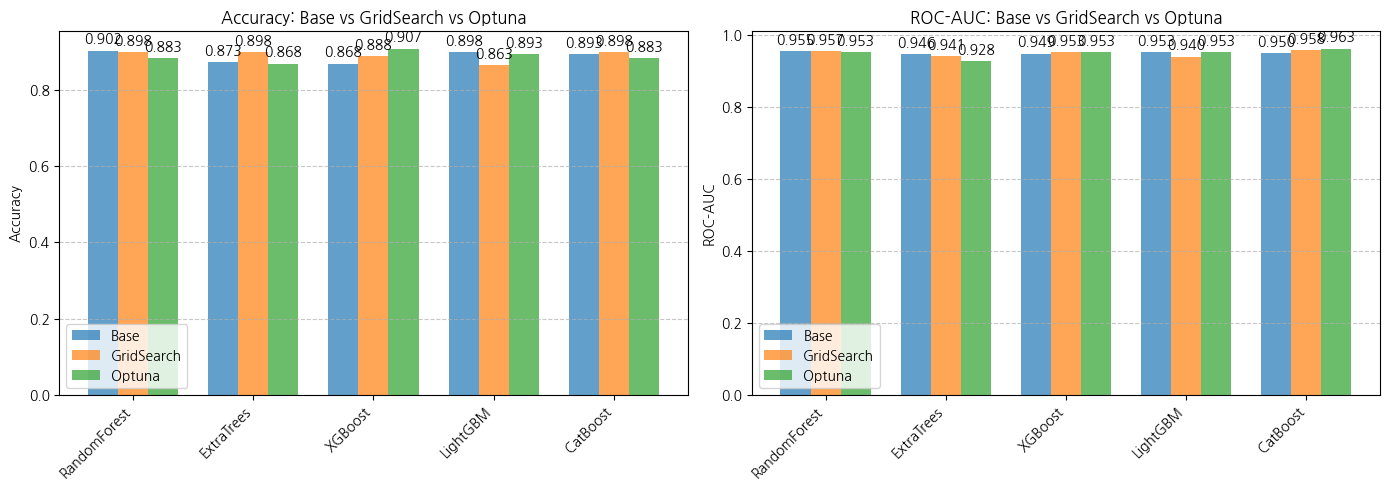

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(comparison_df))
width = 0.25

# Helper function to add labels on top of bars
def autolabel(ax, rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

# Plot for Accuracy
bar_base_acc = axes[0].bar(x - width, comparison_df['Base_Acc'], width, label='Base', alpha=0.7)
bar_grid_acc = axes[0].bar(x, comparison_df['Grid_Acc'], width, label='GridSearch', alpha=0.7)
bar_optuna_acc = axes[0].bar(x + width, comparison_df['Optuna_Acc'], width, label='Optuna', alpha=0.7)
axes[0].set_xticks(x)
axes[0].set_xticklabels(comparison_df['Model'], rotation=45, ha='right')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy: Base vs GridSearch vs Optuna')
axes[0].legend()
axes[0].grid(axis='y', linestyle='--', alpha=0.7) # Add grid
autolabel(axes[0], bar_base_acc)
autolabel(axes[0], bar_grid_acc)
autolabel(axes[0], bar_optuna_acc)

# Plot for ROC-AUC
bar_base_auc = axes[1].bar(x - width, comparison_df['Base_AUC'], width, label='Base', alpha=0.7)
bar_grid_auc = axes[1].bar(x, comparison_df['Grid_AUC'], width, label='GridSearch', alpha=0.7)
bar_optuna_auc = axes[1].bar(x + width, comparison_df['Optuna_AUC'], width, label='Optuna', alpha=0.7)
axes[1].set_xticks(x)
axes[1].set_xticklabels(comparison_df['Model'], rotation=45, ha='right')
axes[1].set_ylabel('ROC-AUC')
axes[1].set_title('ROC-AUC: Base vs GridSearch vs Optuna')
axes[1].legend()
axes[1].grid(axis='y', linestyle='--', alpha=0.7)
autolabel(axes[1], bar_base_auc)
autolabel(axes[1], bar_grid_auc)
autolabel(axes[1], bar_optuna_auc)

plt.tight_layout()
plt.show()

In [19]:
best_idx = optuna_test_df['ROC-AUC'].idxmax()
best_model_name = optuna_test_df.loc[best_idx, 'Model']
best_model = optuna_optimized_models[best_model_name]
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

print(f'Best Model: {best_model_name} (Optuna)')
print(f'Accuracy: {optuna_test_df.loc[best_idx, "Accuracy"]:.4f}')
print(f'ROC-AUC: {optuna_test_df.loc[best_idx, "ROC-AUC"]:.4f}')
print('\n' + classification_report(y_test, y_pred, target_names=['Normal', 'Heart Disease']))

Best Model: CatBoost (Optuna)
Accuracy: 0.8829
ROC-AUC: 0.9625

               precision    recall  f1-score   support

       Normal       0.91      0.82      0.86        92
Heart Disease       0.86      0.94      0.90       113

     accuracy                           0.88       205
    macro avg       0.89      0.88      0.88       205
 weighted avg       0.89      0.88      0.88       205



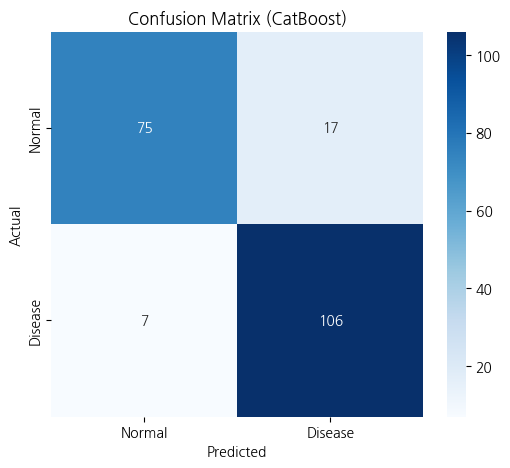

In [20]:
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Disease'], yticklabels=['Normal', 'Disease'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix ({best_model_name})')
plt.show()

## 6. Feature Importance

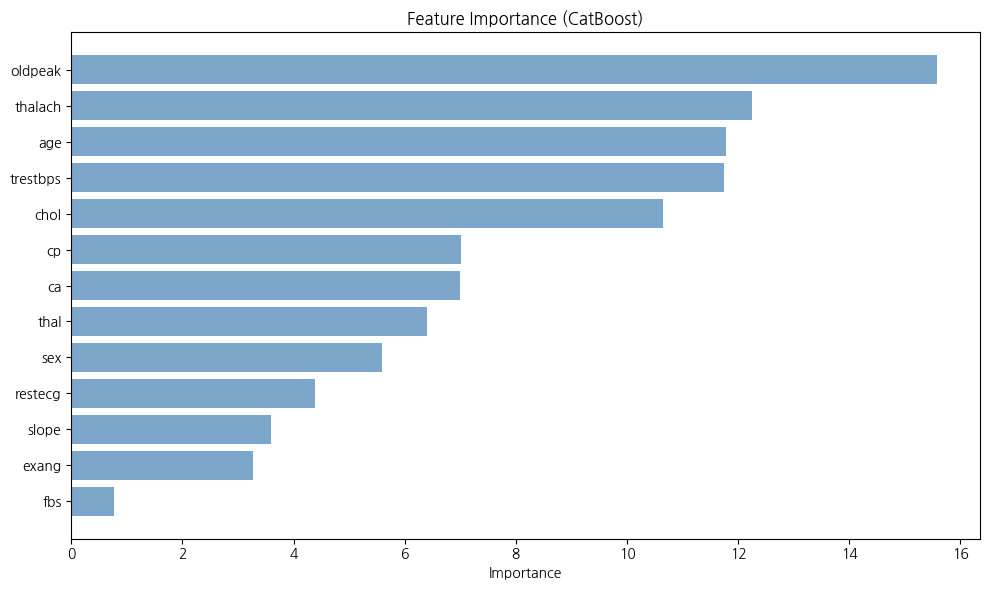

In [21]:
importance_df = pd.DataFrame({'feature': X.columns, 'importance': best_model.feature_importances_}).sort_values('importance', ascending=True)
plt.figure(figsize=(10, 6))
plt.barh(importance_df['feature'], importance_df['importance'], alpha=0.7, color='steelblue')
plt.xlabel('Importance')
plt.title(f'Feature Importance ({best_model_name})')
plt.tight_layout()
plt.show()

## 7. SHAP 해석

In [22]:
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)
shap_values_plot = shap_values[1] if isinstance(shap_values, list) else shap_values
base_value = explainer.expected_value # For binary classification, TreeExplainer for XGBoost might return scalar expected_value
print(f'SHAP values shape: {shap_values_plot.shape}')
# print(f'Base value: {base_value:.4f}')

SHAP values shape: (205, 13)


### 7.1 개별 샘플 SHAP (Waterfall Plot)

In [23]:
y_test_reset = y_test.reset_index(drop=True)
X_test_reset = X_test.reset_index(drop=True)
sample_indices = []
normal_indices = np.where(y_test_reset.values == 0)[0]
disease_indices = np.where(y_test_reset.values == 1)[0]
if len(normal_indices) > 0: sample_indices.append(normal_indices[0])
if len(disease_indices) >= 2: sample_indices.extend(disease_indices[:2])
elif len(disease_indices) == 1: sample_indices.append(disease_indices[0])
print(f'Selected samples: {sample_indices}')
print(f'Actual: {[y_test_reset.iloc[i] for i in sample_indices]}')
print(f'Predicted: {[best_model.predict(X_test_reset.iloc[[i]])[0] for i in sample_indices]}')

Selected samples: [np.int64(0), np.int64(1), np.int64(6)]
Actual: [np.int64(0), np.int64(1), np.int64(1)]
Predicted: [np.int64(0), np.int64(1), np.int64(1)]



=== Sample 1 - Actual: 0, Predicted: 0 ===


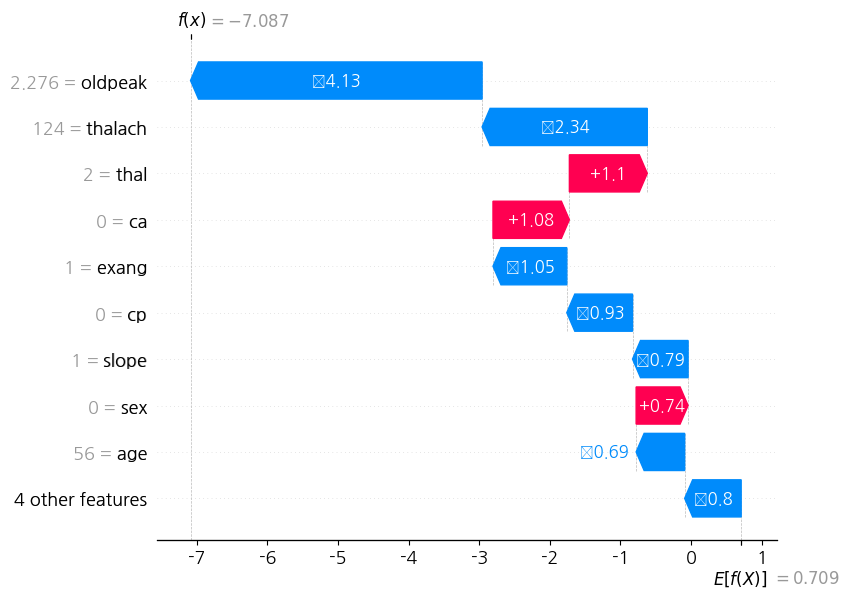


=== Sample 2 - Actual: 1, Predicted: 1 ===


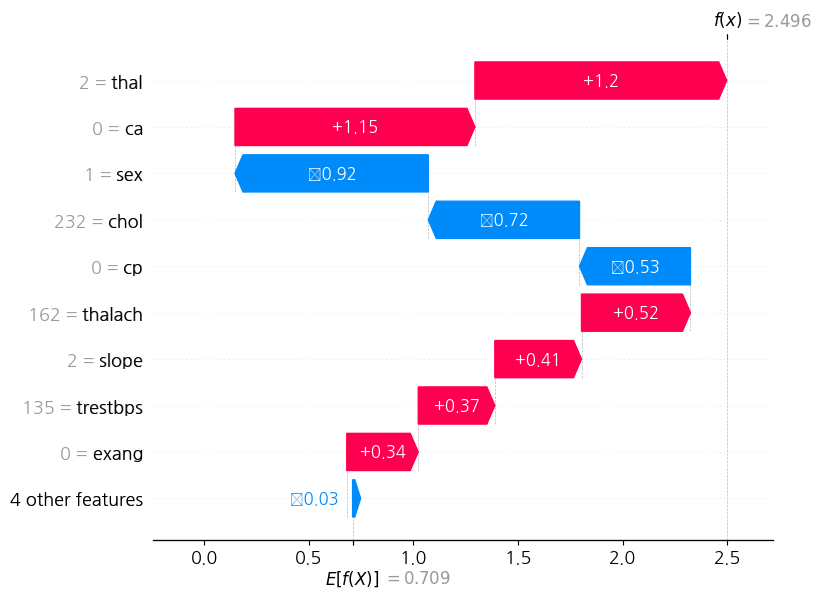


=== Sample 3 - Actual: 1, Predicted: 1 ===


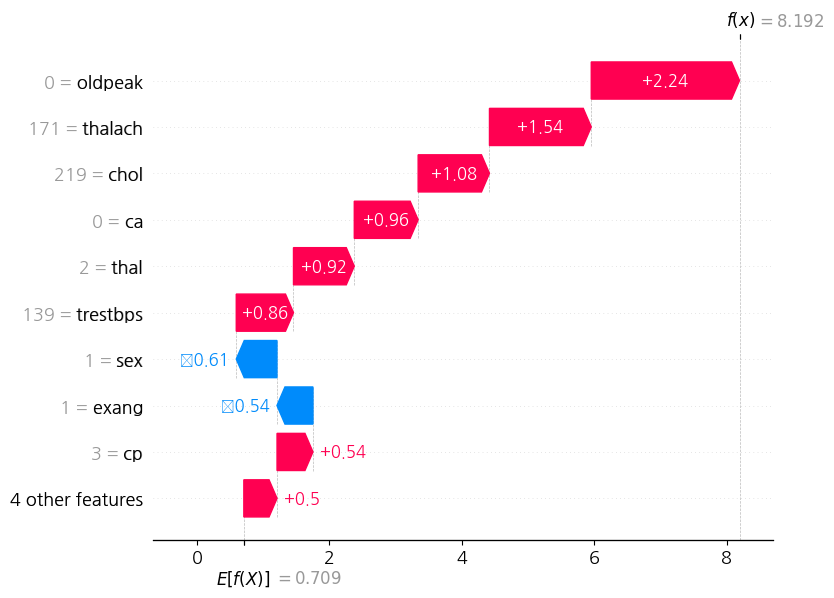

In [24]:
for i, idx in enumerate(sample_indices):
    actual = y_test_reset.iloc[idx]
    pred = best_model.predict(X_test_reset.iloc[[idx]])[0]
    print(f'\n=== Sample {i+1} - Actual: {actual}, Predicted: {pred} ===')
    # Fix: Select SHAP values and base_value for the positive class (class 1)
    shap.waterfall_plot(shap.Explanation(values=shap_values_plot[idx], base_values=base_value, data=X_test_reset.iloc[idx].values, feature_names=X.columns.tolist()), show=True)

### 7.2 Force Plot

In [25]:
import IPython.display

shap.initjs()
for i, idx in enumerate(sample_indices):
    actual = y_test_reset.iloc[idx]
    pred = best_model.predict(X_test_reset.iloc[[idx]])[0]
    print(f'\n=== Sample {i+1} - Actual: {actual}, Predicted: {pred} ===')
    IPython.display.display(shap.force_plot(base_value, shap_values_plot[idx], X_test_reset.iloc[idx], feature_names=X.columns.tolist(), matplotlib=False))


=== Sample 1 - Actual: 0, Predicted: 0 ===



=== Sample 2 - Actual: 1, Predicted: 1 ===



=== Sample 3 - Actual: 1, Predicted: 1 ===


### 7.3 Decision Plot

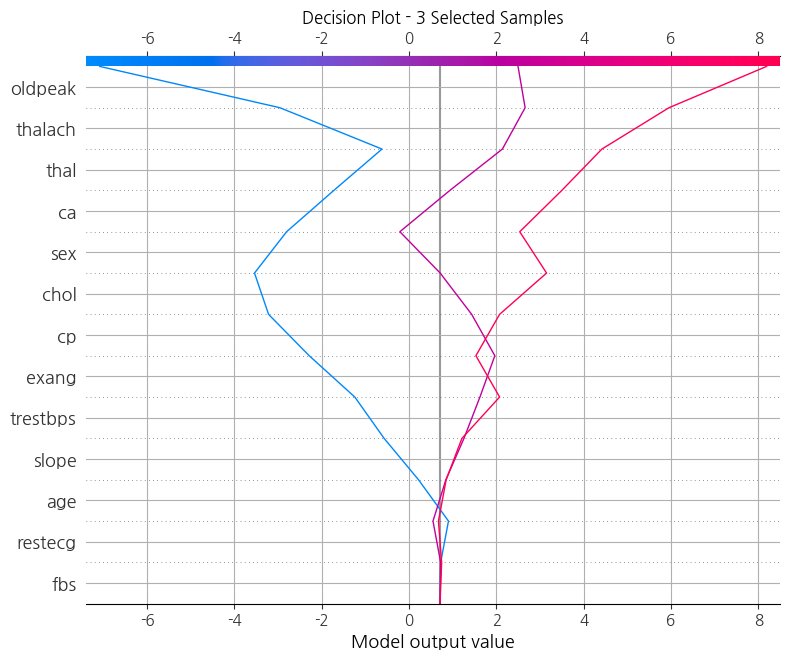

In [26]:
plt.figure(figsize=(10, 8))
shap.decision_plot(base_value, shap_values_plot[sample_indices], X_test_reset.iloc[sample_indices], feature_names=X.columns.tolist(), show=False)
plt.title('Decision Plot - 3 Selected Samples')
plt.grid(True) # Add grid
plt.tight_layout()
plt.show()

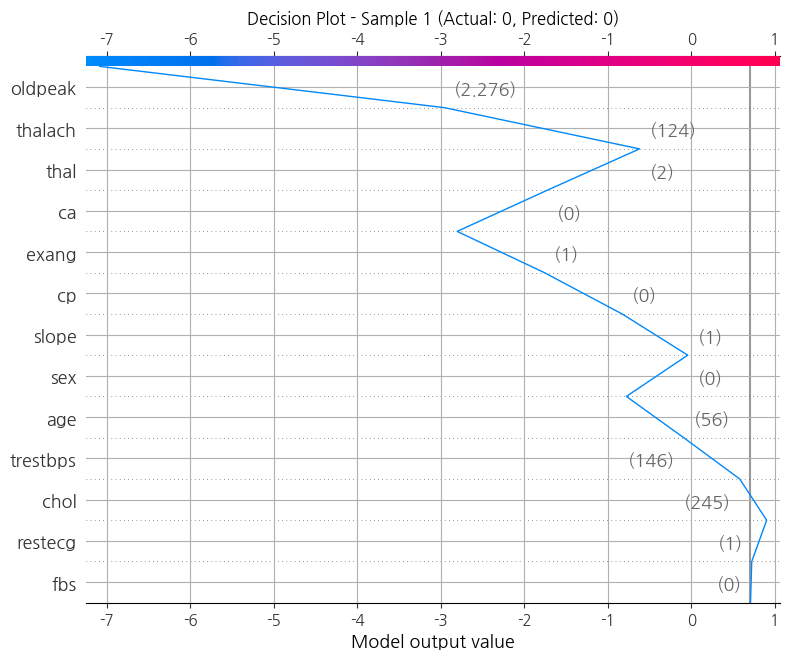

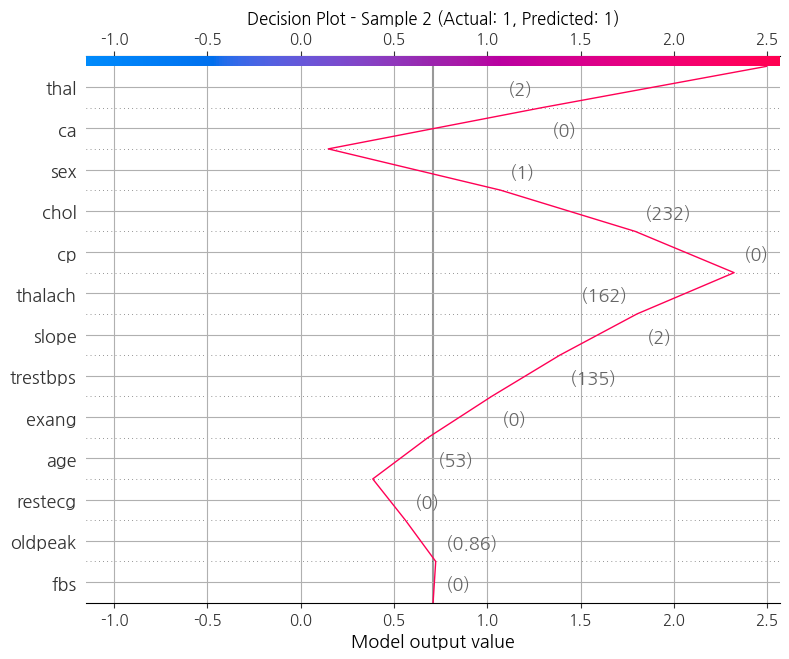

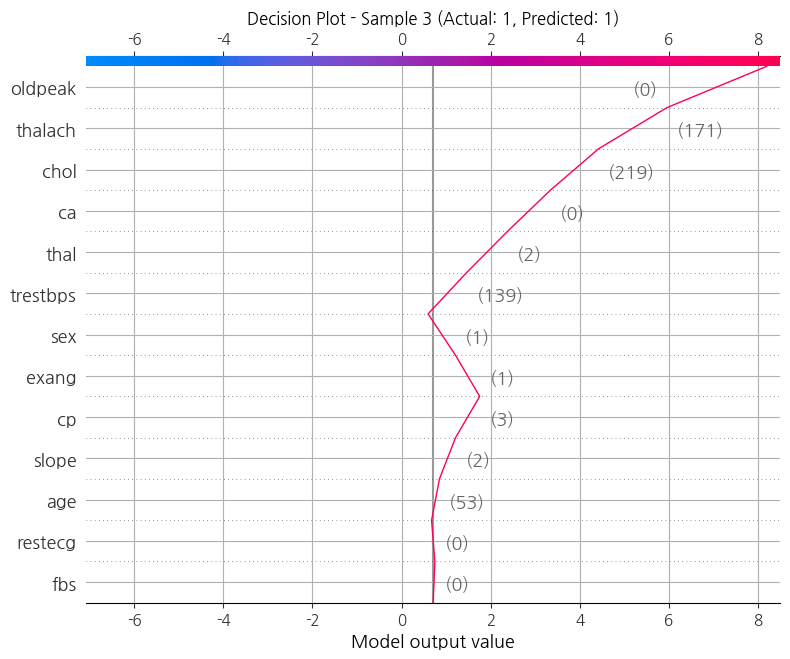

In [27]:
for i, idx in enumerate(sample_indices):
    plt.figure(figsize=(10, 6))
    shap.decision_plot(base_value, shap_values_plot[idx], X_test_reset.iloc[idx], feature_names=X.columns.tolist(), show=False)
    actual = y_test_reset.iloc[idx]
    pred = best_model.predict(X_test_reset.iloc[[idx]])[0]
    plt.title(f'Decision Plot - Sample {i+1} (Actual: {actual}, Predicted: {pred})')
    plt.grid(True) # Add grid
    plt.tight_layout()
    plt.show()

## 8. 최종 결과 요약

In [28]:
summary_data = []
for name in base_models.keys():
    base_acc = base_test_df[base_test_df['Model']==name]['Accuracy'].values[0]
    grid_acc = grid_test_df[grid_test_df['Model']==name]['Accuracy'].values[0]
    optuna_acc = optuna_test_df[optuna_test_df['Model']==name]['Accuracy'].values[0]
    summary_data.append({'Model': name, 'Base': round(base_acc, 4), 'GridSearch': round(grid_acc, 4), 'Optuna': round(optuna_acc, 4), 'Best': round(max(base_acc, grid_acc, optuna_acc), 4)})
summary_df = pd.DataFrame(summary_data)
print('=== 최종 성능 요약 ===')
summary_df

=== 최종 성능 요약 ===


,Model,Base,GridSearch,Optuna,Best
0,RandomForest,0.9024,0.8976,0.8829,0.9024
1,ExtraTrees,0.8732,0.8976,0.8683,0.8976
2,XGBoost,0.8683,0.8878,0.9073,0.9073
3,LightGBM,0.8976,0.8634,0.8927,0.8976
4,CatBoost,0.8927,0.8976,0.8829,0.8976


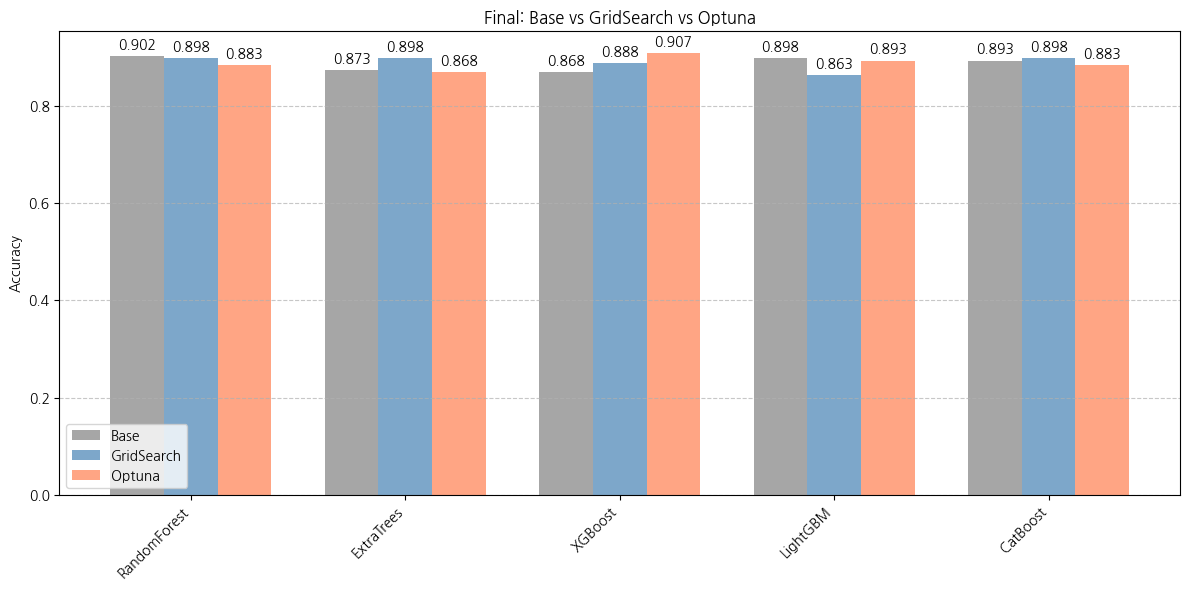

In [29]:
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(summary_df))
width = 0.25

bar1 = ax.bar(x - width, summary_df['Base'], width, label='Base', alpha=0.7, color='gray')
bar2 = ax.bar(x, summary_df['GridSearch'], width, label='GridSearch', alpha=0.7, color='steelblue')
bar3 = ax.bar(x + width, summary_df['Optuna'], width, label='Optuna', alpha=0.7, color='coral')

ax.set_xticks(x)
ax.set_xticklabels(summary_df['Model'], rotation=45, ha='right')
# ax.set_ylim(0.7, 1.0) # Removed this line to allow auto-scaling
ax.set_ylabel('Accuracy')
ax.legend()
ax.set_title('Final: Base vs GridSearch vs Optuna')
ax.grid(axis='y', linestyle='--', alpha=0.7) # Add grid

# Add values on top of the bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(bar1)
autolabel(bar2)
autolabel(bar3)

plt.tight_layout()
plt.show()

In [30]:
print(f'\n=== 최종 선택 모델 ===')
print(f'Model: {best_model_name}')
print(f'Method: Optuna')
print(f'Best Params: {optuna_best_params[best_model_name]}')
print(f'Test F1 Score: {optuna_test_df[optuna_test_df["Model"]==best_model_name]["F1"].values[0]:.4f}')
print(f'Test ROC-AUC: {optuna_test_df[optuna_test_df["Model"]==best_model_name]["ROC-AUC"].values[0]:.4f}')


=== 최종 선택 모델 ===
Model: CatBoost
Method: Optuna
Best Params: {'iterations': 282, 'depth': 8, 'learning_rate': 0.18688826067414144, 'l2_leaf_reg': 1.7811376739874738}
Test F1 Score: 0.8983
Test ROC-AUC: 0.9625
